# Binary Group Composition on $\mathbb{Z}_n^2 \rtimes C_4$

**Group:** $\mathbb{Z}_n^2 \rtimes C_4$ — translations and 90° rotations on the discrete $n \times n$ torus (order $4n^2$).  
**Semidirect product:** The generator $g$ of $C_4$ acts on $\mathbb{Z}_n^2$ via the homomorphism $\varphi(g) = A = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}$, so $(x_1, y_1, r_1) \cdot (x_2, y_2, r_2) = ((x_1, y_1) + A^{r_1}(x_2, y_2) \bmod n,\; r_1 + r_2 \bmod 4)$.  
**Task:** Given encodings of two group elements $g_1, g_2$, predict the encoding of their product $g_1 \cdot g_2$.  
**Sequence length:** $k = 2$ (binary composition).  
**Architecture:** `TwoLayerMLP` with square nonlinearity.

## Imports

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.groups import ZnxZnxC4Group
import src.dataset as dataset
import src.model as model
import src.optimizer as optimizer
import src.template as template
import src.train as train_mod
import src.viz as viz

## Configuration

In [2]:
TEST_MODE = os.environ.get("NOTEBOOK_TEST_MODE", "0") == "1"

seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

n = 3  # Z_3^2 ⋊ C_4 has order 4*9 = 36
group = ZnxZnxC4Group(n)
group_size = group.order

hidden_dim = 20 if TEST_MODE else 600
epochs = 2 if TEST_MODE else 10000
lr = 0.01
init_scale = 1e-3

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Group: Z_{n}^2 ⋊ C_4, order {group_size}")

Group: Z_3^2 ⋊ C_4, order 36


## Template and Dataset

In [3]:
tpl = template.one_hot(group_size)

pair_ds = dataset.GroupCompositionDataset(
    group, template=tpl, k=2, mode="exhaustive",
)
N = len(pair_ds)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = pair_ds.X.to(device)
Y_tensor = pair_ds.Y.to(device)

ds = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(ds, batch_size=len(ds), shuffle=False)

print(f"Dataset: {len(ds)} samples (all {group_size}x{group_size} pairs)")
print(f"X shape: {X_tensor.shape}, Y shape: {Y_tensor.shape}")

Dataset: 1296 samples (all 36x36 pairs)
X shape: torch.Size([1296, 2, 36]), Y shape: torch.Size([1296, 36])


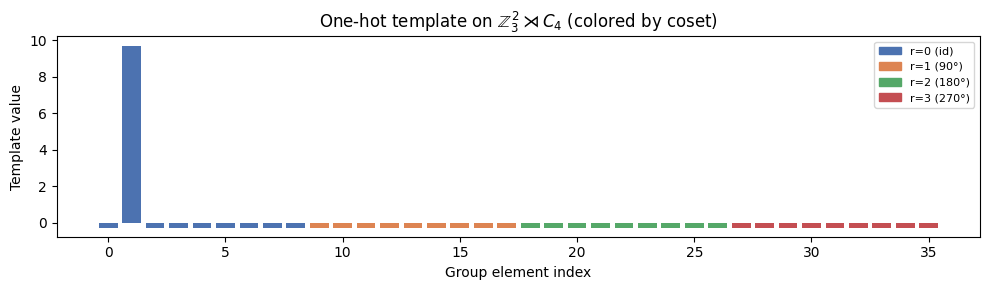

In [4]:
# Visualize template
fig, ax = plt.subplots(figsize=(10, 3))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
coset_labels = ['r=0 (id)', 'r=1 (90°)', 'r=2 (180°)', 'r=3 (270°)']
bar_colors = [colors[idx // (n * n)] for idx in range(group_size)]

ax.bar(range(group_size), tpl, color=bar_colors)
ax.set_xlabel("Group element index")
ax.set_ylabel("Template value")
ax.set_title(f"One-hot template on $\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_4$ (colored by coset)")

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=colors[i], label=coset_labels[i]) for i in range(4)]
ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/znxznxc4_template.pdf", bbox_inches="tight")
plt.show()

## Cayley Table

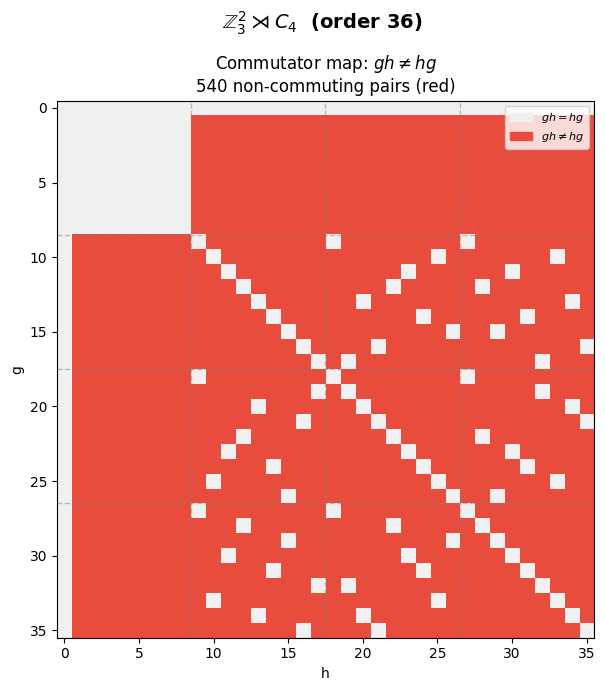

In [5]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

cayley = np.array([[group._cayley(g, h) for h in range(group_size)] for g in range(group_size)])

fig, ax = plt.subplots(figsize=(8, 7))

commutator = (cayley != cayley.T).astype(int)
n_noncommuting = commutator.sum() // 2
cmap_comm = ListedColormap(['#f0f0f0', '#e74c3c'])
ax.imshow(commutator, cmap=cmap_comm, vmin=0, vmax=1)
for pos in np.arange(n * n - 0.5, group_size, n * n):
    ax.axhline(pos, color='gray', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(pos, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('h')
ax.set_ylabel('g')
ax.set_title(f'Commutator map: $gh \\neq hg$\n{n_noncommuting} non-commuting pairs (red)')
patches = [mpatches.Patch(color='#f0f0f0', label='$gh = hg$'),
           mpatches.Patch(color='#e74c3c', label='$gh \\neq hg$')]
ax.legend(handles=patches, fontsize=8, loc='upper right')

plt.suptitle(f'$\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_4$  (order {group_size})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/znxznxc4_cayley.pdf", bbox_inches="tight")
plt.show()

## Model (TwoLayerMLP) and Optimizer

In [6]:
net = model.TwoLayerMLP(
    group_size=group_size,
    hidden_dim=hidden_dim,
    k=2,
    nonlinearity="square",
    init_scale=init_scale,
)
net = net.to(device)

criterion = nn.MSELoss()
opt = optimizer.PerNeuronScaledSGD(net, lr=lr)

print(f"Model: TwoLayerMLP(group_size={group_size}, hidden_dim={hidden_dim}, k=2, init_scale={init_scale})")
print(f"Optimizer: PerNeuronScaledSGD(lr={lr}, degree={opt.param_groups[0]['degree']})")
print(f"Training for {epochs} epochs")

Model: TwoLayerMLP(group_size=36, hidden_dim=600, k=2, init_scale=0.001)
Optimizer: PerNeuronScaledSGD(lr=0.01, degree=2)
Training for 10000 epochs


## Training

In [7]:
loss_history, val_loss_history, param_history, param_save_epochs, final_epoch = train_mod.train(
    net,
    dataloader,
    criterion,
    opt,
    epochs=epochs,
    verbose_interval=max(1, epochs // 10),
    grad_clip=0.1,
    save_param_interval=1,
)

[Epoch  1000 (seg  1000/10000)] loss: 2.700618 | reduction:    0.0%
[Epoch  2000 (seg  2000/10000)] loss: 2.700616 | reduction:    0.0%
[Epoch  3000 (seg  3000/10000)] loss: 2.696306 | reduction:    0.2%
[Epoch  4000 (seg  4000/10000)] loss: 2.604652 | reduction:    3.6%
[Epoch  5000 (seg  5000/10000)] loss: 2.284793 | reduction:   15.4%
[Epoch  6000 (seg  6000/10000)] loss: 1.637292 | reduction:   39.4%
[Epoch  7000 (seg  7000/10000)] loss: 0.953612 | reduction:   64.7%
[Epoch  8000 (seg  8000/10000)] loss: 0.423827 | reduction:   84.3%
[Epoch  9000 (seg  9000/10000)] loss: 0.120263 | reduction:   95.5%
[Epoch 10000 (seg 10000/10000)] loss: 0.028874 | reduction:   98.9%


## Training Loss

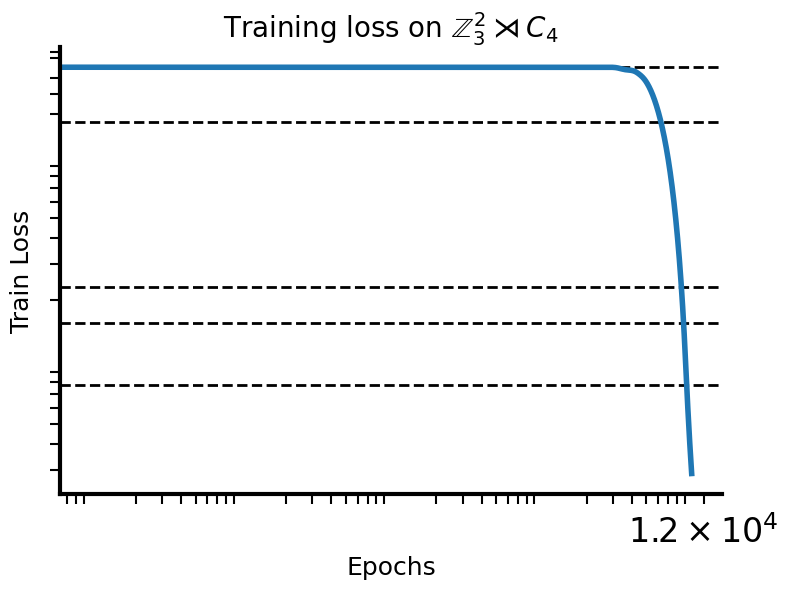

In [8]:
theory_levels = viz.loss_plateau_predictions(tpl, group)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(loss_history, lw=4)

for level in theory_levels:
    ax.axhline(y=level, color="black", linestyle="--", linewidth=2, zorder=-2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"Training loss on $\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_4$", fontsize=20)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/znxznxc4_loss.pdf", bbox_inches="tight")
plt.show()

---

## QuadraticRNN Model

Now we train a `QuadraticRNN` on the same task, using Adam optimizer instead of the neuron-scaled SGD.

In [9]:
rnn_hidden_dim = 20 if TEST_MODE else 600
rnn_epochs = 2 if TEST_MODE else 10000
rnn_lr = 1e-3
rnn_init_scale = 5e-2

rnn_net = model.QuadraticRNN(
    group_size=group_size,
    hidden_dim=rnn_hidden_dim,
    k=2,
    init_scale=rnn_init_scale,
    return_all_outputs=False,
)
rnn_net = rnn_net.to(device)

rnn_criterion = nn.MSELoss()
rnn_opt = torch.optim.Adam(rnn_net.parameters(), lr=rnn_lr)

print(f"Model: QuadraticRNN(group_size={group_size}, hidden_dim={rnn_hidden_dim}, k=2, init_scale={rnn_init_scale})")
print(f"Optimizer: Adam(lr={rnn_lr})")
print(f"Training for {rnn_epochs} epochs")

Model: QuadraticRNN(group_size=36, hidden_dim=600, k=2, init_scale=0.05)
Optimizer: Adam(lr=0.001)
Training for 10000 epochs


### QuadraticRNN Training

In [11]:
rnn_loss_history, rnn_val_loss_history, rnn_param_history, rnn_param_save_epochs, rnn_final_epoch = train_mod.train(
    rnn_net,
    dataloader,
    rnn_criterion,
    rnn_opt,
    epochs=rnn_epochs,
    verbose_interval=max(1, rnn_epochs // 10),
    grad_clip=0.1,
    save_param_interval=1,
)

[Epoch  1000 (seg  1000/10000)] loss: 0.000252 | reduction: -110.2%
[Epoch  2000 (seg  2000/10000)] loss: 0.000078 | reduction:   34.7%
[Epoch  3000 (seg  3000/10000)] loss: 0.000276 | reduction: -130.4%
[Epoch  4000 (seg  4000/10000)] loss: 0.000093 | reduction:   22.5%
[Epoch  5000 (seg  5000/10000)] loss: 0.000129 | reduction:   -7.4%
[Epoch  6000 (seg  6000/10000)] loss: 0.000232 | reduction:  -93.8%
[Epoch  7000 (seg  7000/10000)] loss: 0.000090 | reduction:   25.1%
[Epoch  8000 (seg  8000/10000)] loss: 0.000049 | reduction:   59.2%
[Epoch  9000 (seg  9000/10000)] loss: 0.000258 | reduction: -115.6%
[Epoch 10000 (seg 10000/10000)] loss: 0.000283 | reduction: -136.5%


### QuadraticRNN Training Loss

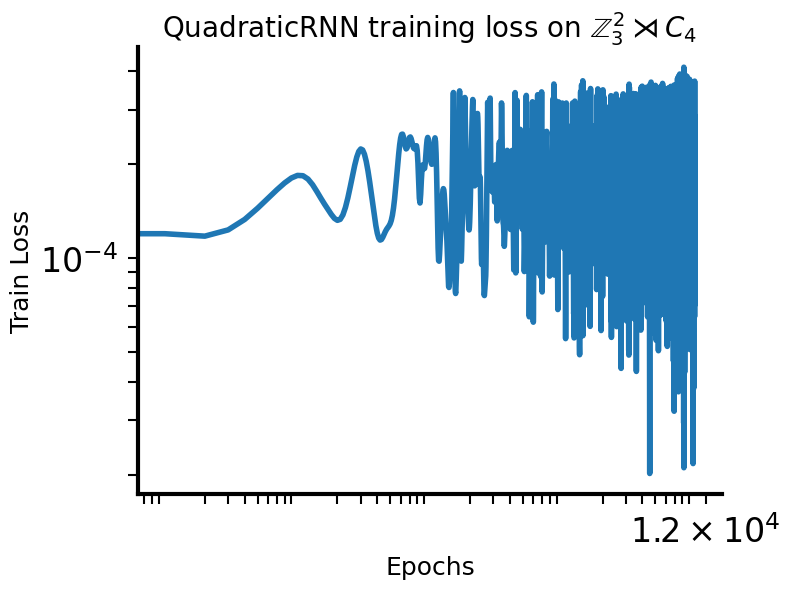

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rnn_loss_history, lw=4)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"QuadraticRNN training loss on $\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_4$", fontsize=20)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/znxznxc4_rnn_loss.pdf", bbox_inches="tight")
plt.show()

### Comparison: TwoLayerMLP vs QuadraticRNN

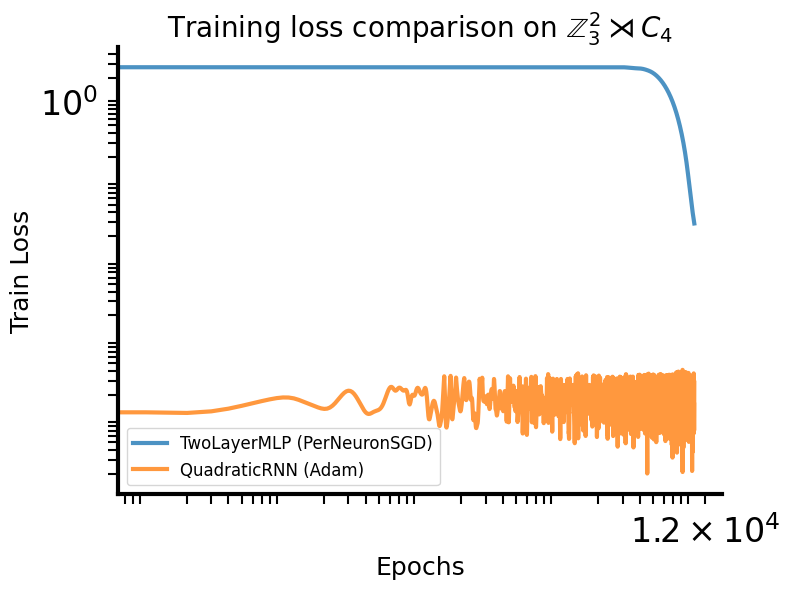

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(loss_history, lw=3, label="TwoLayerMLP (PerNeuronSGD)", alpha=0.8)
ax.plot(rnn_loss_history, lw=3, label="QuadraticRNN (Adam)", alpha=0.8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"Training loss comparison on $\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_4$", fontsize=20)
ax.legend(fontsize=12)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/znxznxc4_comparison.pdf", bbox_inches="tight")
plt.show()

## Power Spectrum Over Training

Computing power at step 1 with output shape (25, 36)
Computing power at step 60 with output shape (25, 36)
Computing power at step 86 with output shape (25, 36)
Computing power at step 121 with output shape (25, 36)
Computing power at step 172 with output shape (25, 36)
Computing power at step 243 with output shape (25, 36)
Computing power at step 344 with output shape (25, 36)
Computing power at step 488 with output shape (25, 36)
Computing power at step 690 with output shape (25, 36)
Computing power at step 977 with output shape (25, 36)
Computing power at step 1382 with output shape (25, 36)
Computing power at step 1956 with output shape (25, 36)
Computing power at step 2768 with output shape (25, 36)
Computing power at step 3917 with output shape (25, 36)
Computing power at step 5542 with output shape (25, 36)
Computing power at step 7842 with output shape (25, 36)


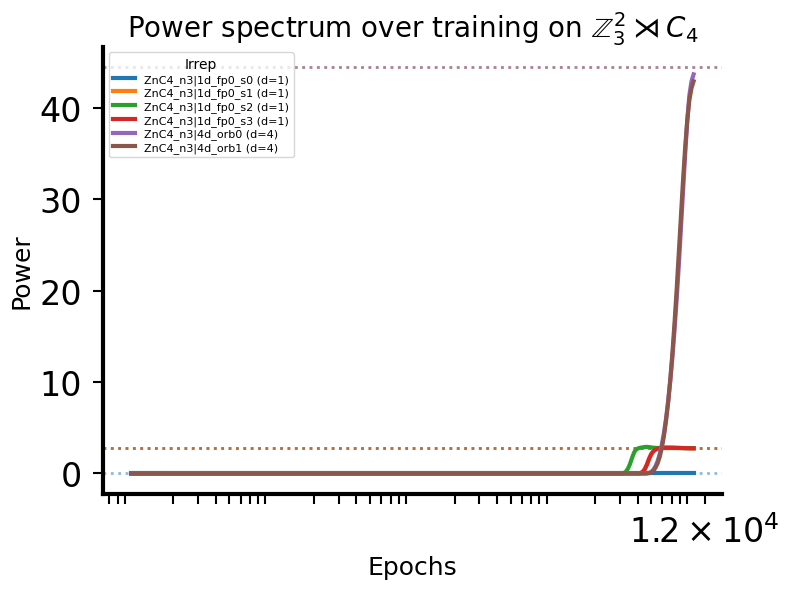

In [17]:
powers_over_time, power_steps = viz.model_power_over_time(
    group,
    model=net,
    param_history=param_history,
    model_inputs=X_tensor,
)

template_pwr = group.power_spectrum(tpl)

irreps = group.irreps()
n_irreps = len(irreps)

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_irreps):
    color = colors[k % len(colors)]
    label = f"{irreps[k]} (d={irreps[k].size})"
    ax.plot(power_steps, powers_over_time[:, k], color=color, lw=3, label=label)
    ax.axhline(template_pwr[k], color=color, linestyle="dotted", linewidth=2, alpha=0.5, zorder=-10)

ax.set_xscale("log")
ax.set_ylabel("Power", fontsize=18)
ax.set_xlabel("Epochs", fontsize=18)
ax.set_title(f"Power spectrum over training on $\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_4$", fontsize=20)
ax.legend(fontsize=8, title="Irrep", title_fontsize=10, loc="upper left", labelspacing=0.25)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/znxznxc4_power_spectrum.pdf", bbox_inches="tight")
plt.show()

## Irreducible Representations

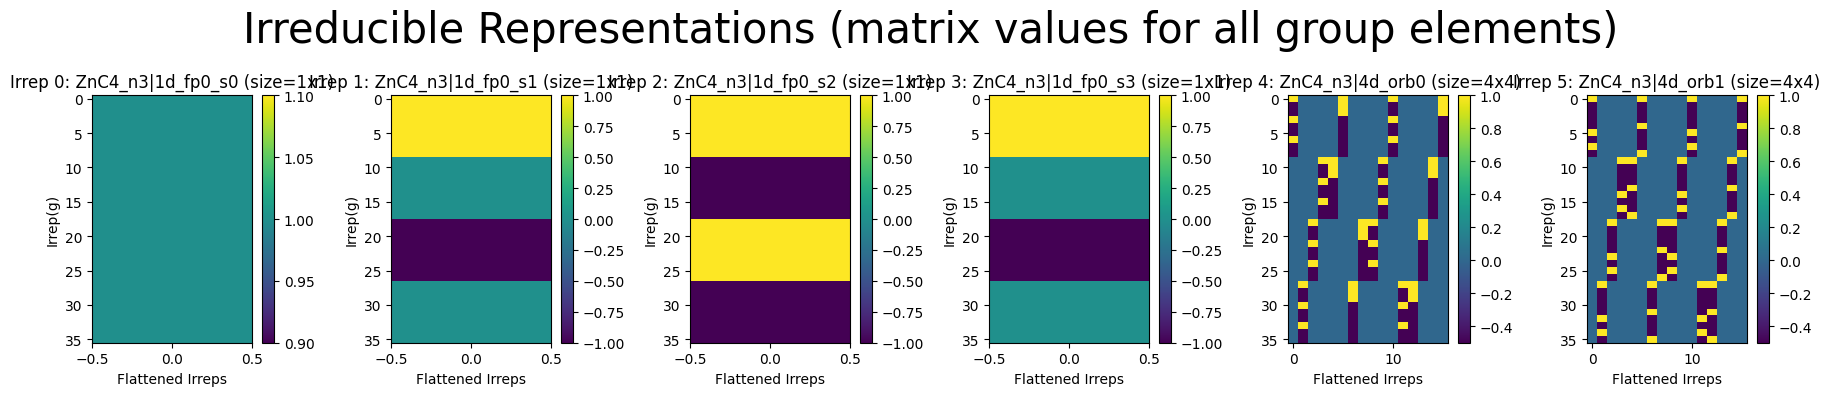

In [15]:
fig = viz.plot_irreps(group, show=False)
plt.savefig(f"{FIGURES_DIR}/znxznxc4_irreps.pdf", bbox_inches="tight")
plt.show()